# Random Forest Pipeline
Multi-class defect classification over 9 categories utilizing flattened pixel features.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from tqdm.notebook import tqdm
import sys
import cv2

# Patch for pandas 2.0+
import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes
try:
    import pandas.core.indexes.base
    sys.modules['pandas.indexes.base'] = pandas.core.indexes.base
except ImportError: pass

## 1. Load Data

In [6]:
print("Loading LSWMD.pkl...")
with open('LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')

def extract_val(x):
    if type(x) == list or type(x).__name__ == 'ndarray':
        if len(x) > 0:
            if type(x[0]) == list or type(x[0]).__name__ == 'ndarray':
                if len(x[0]) > 0: return x[0][0]
                return None
            return x[0]
        return None
    return x

df['failureType'] = df['failureType'].apply(extract_val)
df['trianTestLabel'] = df['trianTestLabel'].apply(extract_val)
df = df.dropna(subset=['failureType'])

labels = df['failureType'].unique().tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}
idx_to_label = {i: l for i, l in enumerate(labels)}
print("Labels:", label_to_idx)

Loading LSWMD.pkl...


/var/folders/m_/4r8l9_rn6jng5pdc6lth0yhr0000gn/T/ipykernel_7328/3869963308.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Labels: {np.str_('none'): 0, np.str_('Loc'): 1, np.str_('Edge-Loc'): 2, np.str_('Center'): 3, np.str_('Edge-Ring'): 4, np.str_('Scratch'): 5, np.str_('Random'): 6, np.str_('Near-full'): 7, np.str_('Donut'): 8}


## 2. Prepare Features

In [7]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['failureType'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

def extract_features(dataset_df, img_size=(32, 32)):
    X, y = [], []
    for idx in tqdm(range(len(dataset_df))):
        wafer = dataset_df.loc[idx, 'waferMap']
        wafer_resized = cv2.resize(wafer, img_size, interpolation=cv2.INTER_NEAREST)
        X.append(wafer_resized.flatten())
        y.append(label_to_idx[dataset_df.loc[idx, 'failureType']])
    return np.array(X), np.array(y)

print("Extracting training features...")
X_train, y_train = extract_features(train_df)
print("Extracting testing features...")
X_test, y_test = extract_features(test_df)

Train samples: 155655, Test samples: 17295
Extracting training features...


  0%|          | 0/155655 [00:00<?, ?it/s]

Extracting testing features...


  0%|          | 0/17295 [00:00<?, ?it/s]

## 3. Train & Evaluate

Training Random Forest Classifier...
Evaluating...
Test Accuracy: 0.9384215091066782


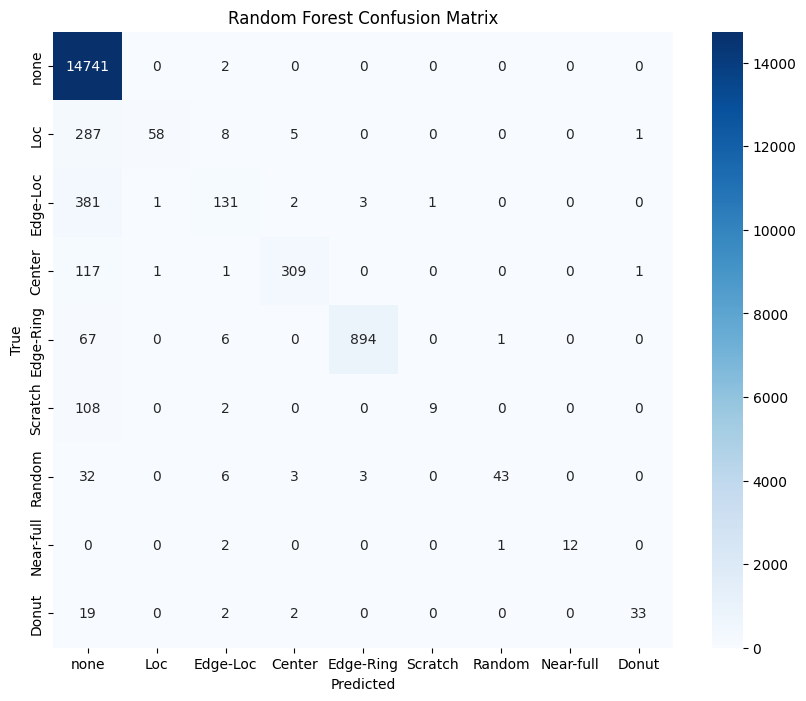

In [8]:
print("Training Random Forest Classifier...")
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

print("Evaluating...")
y_pred = clf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Random Forest Confusion Matrix')
plt.show()